In [11]:
# =====================================================================
# Adversarial Robustness of a Traffic-Sign Classifier (GTSRB)
# Colab: Runtime -> Change runtime type -> T4 GPU. Then run this single cell.
# ~50-70 min. Produces: figs/, results/, physical/, artifacts.zip
# Physical demo: call  physical_demo()  in a new cell at the end.
# =====================================================================
!pip -q install torchattacks==3.5.1 scikit-image

import os, math, json, time, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from PIL import Image
import torchattacks
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEV  = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG, NCLS = 64, 43
MEAN, STD = (0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669)
STD_EPOCHS, ADV_EPOCHS = 8, 8
for d in ['figs', 'results', 'physical']: os.makedirs(d, exist_ok=True)

CLASSES = ['20','30','50','60','70','80','end 80','100','120','no passing',
 'no passing >3.5t','right of way','priority road','yield','STOP','no vehicles',
 'veh >3.5t prohibited','no entry','general caution','curve left','curve right',
 'double curve','bumpy road','slippery road','road narrows','road work',
 'traffic signals','pedestrians','children','bicycles','ice/snow','wild animals',
 'end limits','turn right','turn left','ahead only','straight/right','straight/left',
 'keep right','keep left','roundabout','end no passing','end no passing >3.5t']
STOP, TARGET = 14, 5
R = {}
print(DEV, '| attack story:', CLASSES[STOP], '->', CLASSES[TARGET])

# ------------------------------ DATA ---------------------------------
tf_train = T.Compose([T.Resize((IMG, IMG)),
                      T.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.9, 1.1)),
                      T.ColorJitter(0.3, 0.3, 0.3), T.ToTensor()])
tf_test  = T.Compose([T.Resize((IMG, IMG)), T.ToTensor()])

train_ds = torchvision.datasets.GTSRB('./data', split='train', transform=tf_train, download=True)
test_ds  = torchvision.datasets.GTSRB('./data', split='test',  transform=tf_test,  download=True)
print('train', len(train_ds), '| test', len(test_ds))

train_ld = DataLoader(train_ds, 256, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
test_ld  = DataLoader(test_ds, 512, shuffle=False, num_workers=2, pin_memory=True)

test_labels = np.array([t for _, t in test_ds._samples])
g = torch.Generator().manual_seed(SEED)
eval_idx = torch.randperm(len(test_ds), generator=g)[:2000].tolist()
eval_ld  = DataLoader(Subset(test_ds, eval_idx), 256, shuffle=False, num_workers=2)
stop_idx = np.where(test_labels == STOP)[0].tolist()
stop_ld  = DataLoader(Subset(test_ds, stop_idx), 256, shuffle=False)
print('eval subset 2000 | STOP images', len(stop_idx))


cuda | attack story: STOP -> 80
train 26640 | test 12630
eval subset 2000 | STOP images 270


In [12]:
# ------------------------------ MODEL --------------------------------
class Normalize(nn.Module):
    """Normalization inside the model => attacks operate in true [0,1] pixel space."""
    def __init__(s, m, sd):
        super().__init__()
        s.register_buffer('m', torch.tensor(m).view(1, 3, 1, 1))
        s.register_buffer('s', torch.tensor(sd).view(1, 3, 1, 1))
    def forward(s, x): return (x - s.m) / s.s

def make_resnet18():
    m = torchvision.models.resnet18(weights='IMAGENET1K_V1')
    m.fc = nn.Linear(512, NCLS)
    return nn.Sequential(Normalize(MEAN, STD), m).to(DEV)

@torch.no_grad()
def accuracy(model, loader):
    model.eval(); c = n = 0
    for x, y in loader:
        x, y = x.to(DEV), y.to(DEV)
        c += (model(x).argmax(1) == y).sum().item(); n += y.numel()
    return 100.0 * c / n

def pgd_batch(model, x, y, eps, alpha, steps):
    d = (torch.rand_like(x) * 2 - 1) * eps
    d = (x + d).clamp(0, 1) - x
    for _ in range(steps):
        d.requires_grad_(True)
        gr, = torch.autograd.grad(F.cross_entropy(model(x + d), y), d)
        d = (d.detach() + alpha * gr.sign()).clamp(-eps, eps)
        d = (x + d).clamp(0, 1) - x
    return (x + d).detach()

def train(model, epochs, lr=1e-3, adv=False, eps=8/255, alpha=2/255, steps=7, tag='std'):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr,
                                              total_steps=epochs * len(train_ld))
    for ep in range(epochs):
        model.train(); t0 = time.time(); run = 0.0
        for x, y in train_ld:
            x, y = x.to(DEV, non_blocking=True), y.to(DEV, non_blocking=True)
            if adv:
                model.eval(); x = pgd_batch(model, x, y, eps, alpha, steps); model.train()
            loss = F.cross_entropy(model(x), y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
            run += loss.item()
        print(f'[{tag}] ep {ep+1}/{epochs} loss {run/len(train_ld):.4f} '
              f'eval {accuracy(model, eval_ld):.2f}%  {time.time()-t0:.0f}s')
    return model

# ------------------------- v1: standard ResNet-18 --------------------
print('\n=== v1: standard ResNet-18 ===')
R = globals().get('R', {})
cnn = make_resnet18()
if os.path.exists('cnn_std.pt'):
    cnn.load_state_dict(torch.load('cnn_std.pt', map_location=DEV)); print('loaded cnn_std.pt')
else:
    train(cnn, STD_EPOCHS, tag='std'); torch.save(cnn.state_dict(), 'cnn_std.pt')
cnn.eval()
R['clean_cnn'] = accuracy(cnn, test_ld)
json.dump({k: float(v) for k, v in R.items()}, open('results/results.json', 'w'), indent=2)
print(f">>> clean test accuracy: {R['clean_cnn']:.2f}%")


=== v1: standard ResNet-18 ===
loaded cnn_std.pt
>>> clean test accuracy: 97.95%


In [13]:
# ================= v0: classical HOG + LinearSVM (GPU, fast) =================
import os, time, math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

HOG_RES, N_SUB, CACHE = 64, 20000, 'hog64.npz'   # 64x64 -> 1764-dim descriptor
R = globals().get('R', {})

# ---- vectorized HOG on GPU (hard binning + L2-Hys, ~skimage defaults) ----
@torch.no_grad()
def hog_torch(x, orientations=9, ppc=8, cpb=2, eps=1e-5, res=HOG_RES):
    if x.shape[-1] != res or x.shape[-2] != res:
        x = F.interpolate(x, (res, res), mode='bilinear', align_corners=False)
    g = (0.299 * x[:, 0] + 0.587 * x[:, 1] + 0.114 * x[:, 2]).unsqueeze(1)
    gx = torch.zeros_like(g); gy = torch.zeros_like(g)
    gx[..., :, 1:-1] = g[..., :, 2:] - g[..., :, :-2]
    gy[..., 1:-1, :] = g[..., 2:, :] - g[..., :-2, :]
    mag = torch.sqrt(gx * gx + gy * gy)
    ang = torch.atan2(gy, gx) % math.pi
    b = (ang / (math.pi / orientations)).long().clamp_(0, orientations - 1)
    B, _, H, W = g.shape
    oh = torch.zeros(B, orientations, H, W, device=g.device, dtype=g.dtype)
    oh.scatter_(1, b, mag)                                  # magnitude-weighted votes
    cells = F.avg_pool2d(oh, ppc) * (ppc * ppc)             # sum-pool -> cell hists
    blk = F.unfold(cells, kernel_size=cpb)                  # (B, O*cpb*cpb, nblocks)
    blk = blk / (blk.norm(dim=1, keepdim=True) + eps)
    blk = blk.clamp(max=0.2)
    blk = blk / (blk.norm(dim=1, keepdim=True) + eps)
    return blk.flatten(1).float()

@torch.no_grad()
def feats_from_loader(ld):
    Fs, Ys = [], []
    for x, y in ld:
        Fs.append(hog_torch(x.to(DEV, non_blocking=True)).cpu())
        Ys.append(y)
    return torch.cat(Fs).numpy(), torch.cat(Ys).numpy()

# ---- linear SVM (multiclass squared hinge = LinearSVC objective) on GPU ----
def linear_svm_gpu(Ftr, Ytr, Fte, Yte, ncls, C=1.0, epochs=40, bs=1024, lr=3e-3):
    Xtr = torch.as_tensor(Ftr, device=DEV, dtype=torch.float32)
    Xte = torch.as_tensor(Fte, device=DEV, dtype=torch.float32)
    ytr = torch.as_tensor(Ytr, device=DEV).long()
    yte = torch.as_tensor(Yte, device=DEV).long()
    m, s = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True) + 1e-6
    Xtr, Xte = (Xtr - m) / s, (Xte - m) / s
    W = nn.Linear(Xtr.shape[1], ncls).to(DEV)
    opt = torch.optim.AdamW(W.parameters(), lr=lr, weight_decay=1.0 / (C * len(Xtr)))
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in range(epochs):
        perm = torch.randperm(len(Xtr), device=DEV)
        for i in range(0, len(Xtr), bs):
            j = perm[i:i + bs]
            loss = F.multi_margin_loss(W(Xtr[j]), ytr[j], p=2)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sch.step()
    with torch.no_grad():
        tr = 100.0 * (W(Xtr).argmax(1) == ytr).float().mean().item()
        te = 100.0 * (W(Xte).argmax(1) == yte).float().mean().item()
    return W, te, tr, (m, s)

# ------------------------------- run -------------------------------
print('\n=== v0: classical HOG + LinearSVM baseline ===')
if os.path.exists(CACHE):
    z = np.load(CACHE); Ftr, Ytr, Fte, Yte = z['a'], z['b'], z['c'], z['d']
    print(f'loaded cached features {Ftr.shape}')
else:
    old_tf = train_ds.transform
    try:
        train_ds.transform = tf_test                       # no augmentation for features
        sub = torch.randperm(len(train_ds),
              generator=torch.Generator().manual_seed(1))[:N_SUB].tolist()
        t0 = time.time()
        Ftr, Ytr = feats_from_loader(
            DataLoader(Subset(train_ds, sub), 512, num_workers=2, pin_memory=True))
        print(f'train feats {Ftr.shape} in {time.time()-t0:.1f}s')
    finally:
        train_ds.transform = old_tf                        # restored even on interrupt
    t0 = time.time()
    Fte, Yte = feats_from_loader(test_ld)
    print(f'test  feats {Fte.shape} in {time.time()-t0:.1f}s')
    np.savez_compressed(CACHE, a=Ftr, b=Ytr, c=Fte, d=Yte)

assert Ftr.shape[1] < 5000, f'HOG dim {Ftr.shape[1]} too large — HOG_RES did not apply'
t0 = time.time()
svm_W, R['clean_svm'], tr_acc, svm_norm = linear_svm_gpu(Ftr, Ytr, Fte, Yte, NCLS)
print(f'svm fit {time.time()-t0:.1f}s  (train {tr_acc:.2f}%)')
print(f">>> HOG+SVM clean test accuracy: {R['clean_svm']:.2f}%")


=== v0: classical HOG + LinearSVM baseline ===
loaded cached features (20000, 1764)
svm fit 0.8s  (train 99.96%)
>>> HOG+SVM clean test accuracy: 86.89%



=== v2: digital white-box, standard model ===
{'model': 'standard', 'eps_255': 0, 'FGSM': 97.6, 'PGD20': 97.6}
{'model': 'standard', 'eps_255': 1.0, 'FGSM': 82.5, 'PGD20': 68.1}
{'model': 'standard', 'eps_255': 2.0, 'FGSM': 66.2, 'PGD20': 33.1}
{'model': 'standard', 'eps_255': 4.0, 'FGSM': 49.0, 'PGD20': 7.8}
{'model': 'standard', 'eps_255': 8.0, 'FGSM': 32.6, 'PGD20': 0.3}
{'model': 'standard', 'eps_255': 16.0, 'FGSM': 21.8, 'PGD20': 0.0}


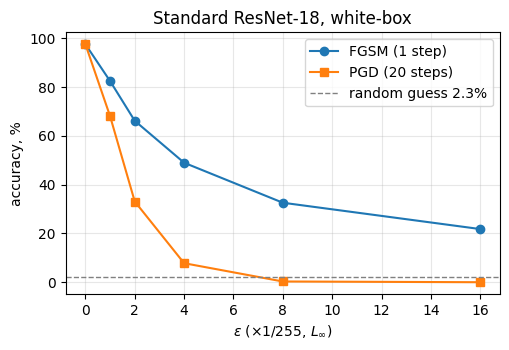

CNN on same PGD examples: 0.20%
HOG+SVM: clean 86.40% -> transferred PGD 56.30%

=== v3: physical-world universal patch (EOT) ===
-- patch WITH EOT (base 13px) --
   it   0 loss 9.510
   it 100 loss 3.209
   it 200 loss 3.157
   it 300 loss 2.730
-- patch WITHOUT EOT (base 13px) --
   it   0 loss 8.260
   it 100 loss 1.780
   it 200 loss 1.382
   it 300 loss 1.158
EOT patch: all 42.9% | STOP only 71.0%
no-EOT patch: ideal 72.7% -> transformed 36.4%
base 6px | area 0.9% | ASR 11.1%
base 8px | area 1.6% | ASR 17.1%
base 10px | area 2.4% | ASR 25.6%
base 13px | area 4.1% | ASR 42.4%
base 15px | area 5.5% | ASR 55.8%


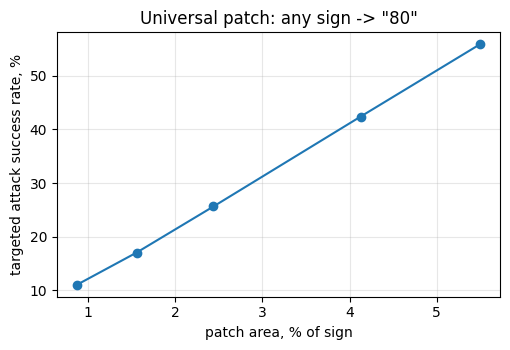


=== v4: PGD adversarial training (defense) ===
[adv] ep 1/8 loss 4.1765 eval 22.90%  54s
[adv] ep 2/8 loss 2.5806 eval 51.50%  54s
[adv] ep 3/8 loss 1.8220 eval 67.35%  54s
[adv] ep 4/8 loss 1.4403 eval 73.85%  54s
[adv] ep 5/8 loss 1.2597 eval 80.10%  54s
[adv] ep 6/8 loss 1.1218 eval 83.65%  54s
[adv] ep 7/8 loss 1.0179 eval 83.65%  54s
[adv] ep 8/8 loss 0.9641 eval 84.40%  54s
{'model': 'adv-trained', 'eps_255': 0, 'FGSM': 84.4, 'PGD20': 84.4}
{'model': 'adv-trained', 'eps_255': 1.0, 'FGSM': 81.5, 'PGD20': 81.4}
{'model': 'adv-trained', 'eps_255': 2.0, 'FGSM': 78.7, 'PGD20': 78.2}
{'model': 'adv-trained', 'eps_255': 4.0, 'FGSM': 72.8, 'PGD20': 71.1}
{'model': 'adv-trained', 'eps_255': 8.0, 'FGSM': 61.9, 'PGD20': 50.6}
{'model': 'adv-trained', 'eps_255': 16.0, 'FGSM': 43.2, 'PGD20': 20.5}


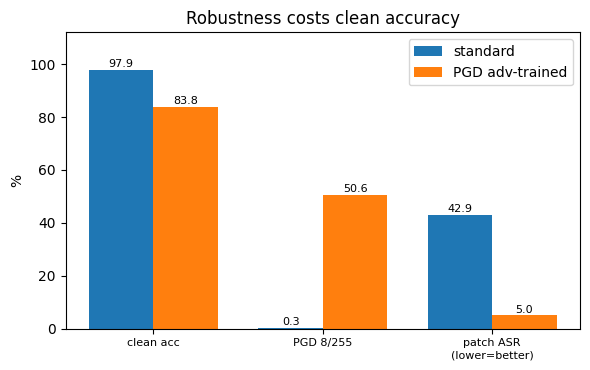

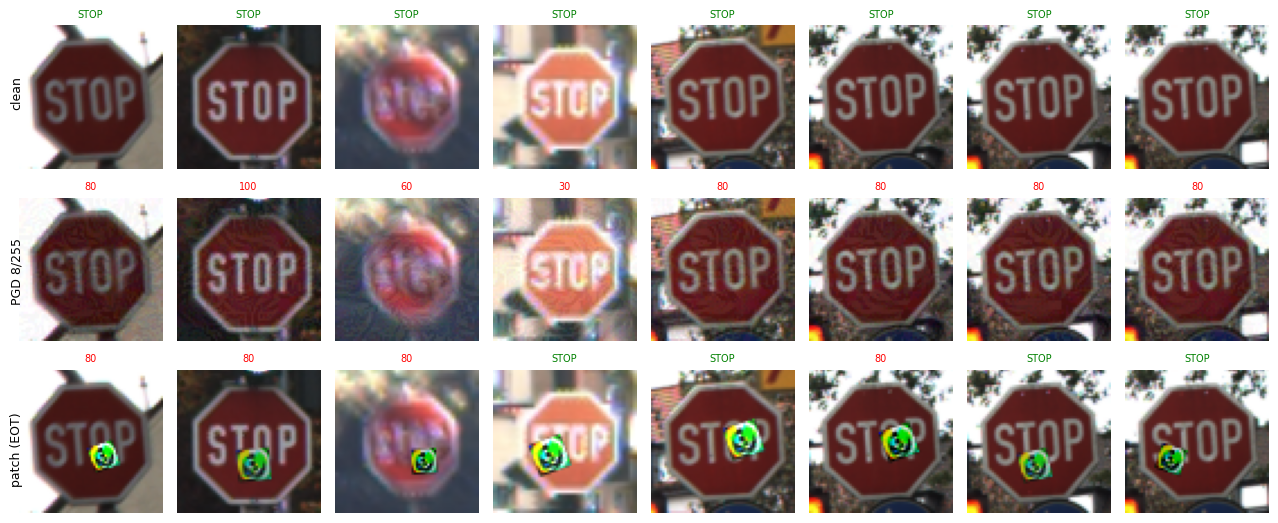

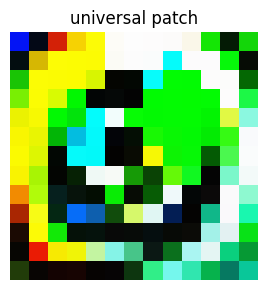


                      model  clean acc % FGSM 8/255 %     PGD 8/255 % patch ASR %
HOG + LinearSVM (classical)        86.89            - 56.3 (transfer)           -
       ResNet-18 (standard)        97.95         32.6             0.3       42.91
ResNet-18 (PGD adv-trained)        83.84            -            50.6        5.02

EOT ablation: 72.74% ideal placement -> 36.35% transformed
STOP-only patch ASR: 70.99%
(attack metrics computed on a fixed 1000-image subset)

DONE. artifacts.zip is in the Files pane (left sidebar).
For the real-world attack slide, run  physical_demo()  in a new cell.


In [14]:
# ========== v2b/v3/v4/v5: transfer, patch, adv-training, figures ==========
import os, json, math, time
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, torchattacks
from PIL import Image
from torch.utils.data import DataLoader, Subset

for _d in ('figs', 'results', 'physical'):
    os.makedirs(_d, exist_ok=True)
R = globals().get('R', {})
assert 'clean_svm' in R and 'svm_W' in globals(), 'run the v0 HOG/SVM cell first'
_ii = lambda seq, n=None: [int(v) for v in (seq[:n] if n else seq)]

# ---- small fixed eval subset: attack curves are ~100x a clean eval ----
CURVE_N = 1000
_bs = getattr(eval_ld, 'batch_size', None) or 128
curve_ld = DataLoader(Subset(test_ds, _ii(eval_idx, CURVE_N)),
                      batch_size=_bs, num_workers=2, pin_memory=True)

def robust_acc(model, atk, loader):
    model.eval(); c = n = 0
    for x, y in loader:
        x, y = x.to(DEV), y.to(DEV)
        xa = atk(x, y)
        with torch.no_grad():
            c += (model(xa).argmax(1) == y).sum().item()
        n += y.numel()
    return 100.0 * c / n

def eps_curve(model, name, loader=None):
    loader = loader if loader is not None else curve_ld
    rows = []
    for e in [0, 1/255, 2/255, 4/255, 8/255, 16/255]:
        if e == 0:
            fg = pg = accuracy(model, loader)
        else:
            fg = robust_acc(model, torchattacks.FGSM(model, eps=e), loader)
            pg = robust_acc(model, torchattacks.PGD(model, eps=e, alpha=max(e/4, 1/255),
                                                    steps=20, random_start=True), loader)
        rows.append(dict(model=name, eps_255=round(e * 255, 1), FGSM=fg, PGD20=pg))
        print(rows[-1])
    return pd.DataFrame(rows)

# reuse the curve from the previous cell instead of recomputing it
_prev = next((v for k, v in list(globals().items())
              if k.endswith('curves') and isinstance(v, list) and v
              and isinstance(v[0], pd.DataFrame) and 'PGD20' in v[0].columns), None)
if _prev is not None:
    dig_std = _prev[0].assign(model='standard'); print('reusing cached dig_std')
else:
    print('\n=== v2: digital white-box, standard model ===')
    dig_std = eps_curve(cnn, 'standard')

R['fgsm8_cnn'] = float(dig_std.loc[dig_std.eps_255 == 8.0, 'FGSM'].iloc[0])
R['pgd8_cnn']  = float(dig_std.loc[dig_std.eps_255 == 8.0, 'PGD20'].iloc[0])

plt.figure(figsize=(5.2, 3.6))
plt.plot(dig_std.eps_255, dig_std.FGSM, 'o-', label='FGSM (1 step)')
plt.plot(dig_std.eps_255, dig_std.PGD20, 's-', label='PGD (20 steps)')
plt.axhline(100 / NCLS, ls='--', c='gray', lw=1, label=f'random guess {100/NCLS:.1f}%')
plt.xlabel(r'$\epsilon$ ($\times$1/255, $L_\infty$)'); plt.ylabel('accuracy, %')
plt.title('Standard ResNet-18, white-box'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('figs/acc_vs_eps.png', dpi=200); plt.show()

# ---------------- transfer: CNN-PGD examples -> HOG+SVM ----------------
@torch.no_grad()
def svm_predict(x01, bs=256):
    """x01: CPU or GPU tensor (N,3,H,W) in [0,1] -> predicted labels (numpy)."""
    m, s = svm_norm; out = []
    for i in range(0, len(x01), bs):
        f = hog_torch(x01[i:i + bs].to(DEV))
        out.append(svm_W((f - m) / s).argmax(1).cpu())
    return torch.cat(out).numpy()

def attack_batched(atk, x_cpu, y_cpu, bs=64):
    """Run a torchattacks attack in chunks; keeps results on CPU (avoids OOM)."""
    outs = []
    for i in range(0, len(x_cpu), bs):
        outs.append(atk(x_cpu[i:i + bs].to(DEV), y_cpu[i:i + bs].to(DEV)).detach().cpu())
    return torch.cat(outs)

tr_idx = _ii(eval_idx, 1000)
xs = torch.stack([test_ds[i][0] for i in tr_idx])          # stays on CPU
ys = torch.tensor([test_ds[i][1] for i in tr_idx])
xa = attack_batched(torchattacks.PGD(cnn, eps=8/255, alpha=2/255, steps=20,
                                     random_start=True), xs, ys, bs=64)
yn = ys.numpy()
R['svm_clean_sub'] = 100.0 * (svm_predict(xs) == yn).mean()
R['svm_transfer']  = 100.0 * (svm_predict(xa) == yn).mean()
with torch.no_grad():
    _c = sum((cnn(xa[i:i+128].to(DEV)).argmax(1).cpu() == ys[i:i+128]).sum().item()
             for i in range(0, len(xa), 128))
print(f"CNN on same PGD examples: {100.0*_c/len(xa):.2f}%")
print(f"HOG+SVM: clean {R['svm_clean_sub']:.2f}% -> transferred PGD {R['svm_transfer']:.2f}%")

# ------------- v3: PHYSICAL UNIVERSAL PATCH WITH EOT -----------------
print('\n=== v3: physical-world universal patch (EOT) ===')
def paste_patch(x, patch, eot=True):
    """Differentiable composite of patch onto x with random scale/rotation/
       translation/brightness = Expectation Over Transformation (Athalye+ 2018)."""
    B, _, H, W = x.shape
    p = patch.unsqueeze(0).expand(B, -1, -1, -1); ph, pw = p.shape[-2:]
    top, left = (H - ph) // 2, (W - pw) // 2
    pad = (left, W - pw - left, top, H - ph - top)
    canvas = F.pad(p, pad)
    mask = F.pad(torch.ones(B, 1, ph, pw, device=x.device, dtype=x.dtype), pad)
    if eot:
        s  = torch.empty(B, device=x.device).uniform_(0.75, 1.30)
        a  = torch.empty(B, device=x.device).uniform_(-25, 25) * math.pi / 180
        tx = torch.empty(B, device=x.device).uniform_(-0.40, 0.40)
        ty = torch.empty(B, device=x.device).uniform_(-0.05, 0.45)
        br = torch.empty(B, 1, 1, 1, device=x.device).uniform_(0.65, 1.25)
        bi = torch.empty(B, 1, 1, 1, device=x.device).uniform_(-0.08, 0.08)
    else:
        s  = torch.ones(B, device=x.device);  a  = torch.zeros(B, device=x.device)
        tx = torch.zeros(B, device=x.device); ty = torch.full((B,), 0.30, device=x.device)
        br = torch.ones(B, 1, 1, 1, device=x.device)
        bi = torch.zeros(B, 1, 1, 1, device=x.device)
    c, s_, inv = torch.cos(a), torch.sin(a), 1.0 / s
    M = torch.stack([torch.stack([c * inv,   s_ * inv], -1),
                     torch.stack([-s_ * inv, c * inv ], -1)], -2)
    t = torch.stack([tx, ty], -1).unsqueeze(-1)
    theta = torch.cat([M, -M @ t], dim=2)
    grid = F.affine_grid(theta, size=list(x.shape), align_corners=False)
    cw = F.grid_sample(canvas, grid, align_corners=False, padding_mode='zeros')
    mw = F.grid_sample(mask,   grid, align_corners=False, padding_mode='zeros')
    return x * (1 - mw) + (cw * br + bi).clamp(0, 1) * mw

def train_patch(model, base=20, iters=400, eot=True, lr=0.05, verbose=True):
    model.eval()
    flags = [q.requires_grad for q in model.parameters()]
    for q in model.parameters(): q.requires_grad_(False)
    w = torch.zeros(3, base, base, device=DEV).uniform_(-0.5, 0.5).requires_grad_(True)
    opt = torch.optim.Adam([w], lr=lr); it = iter(train_ld)
    for i in range(iters):
        try: x, _ = next(it)
        except StopIteration: it = iter(train_ld); x, _ = next(it)
        x = x.to(DEV, non_blocking=True)
        tgt = torch.full((x.size(0),), TARGET, device=DEV, dtype=torch.long)
        loss = F.cross_entropy(model(paste_patch(x, torch.sigmoid(w), eot=eot)), tgt)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        if verbose and i % 100 == 0: print(f'   it {i:3d} loss {loss.item():.3f}')
    for q, f in zip(model.parameters(), flags): q.requires_grad_(f)
    return torch.sigmoid(w).detach()

@torch.no_grad()
def patch_asr(model, patch, loader, eot=True, reps=3):
    model.eval(); hit = n = 0
    for _ in range(reps):
        for x, y in loader:
            x, y = x.to(DEV), y.to(DEV); k = y != TARGET
            if k.sum() == 0: continue
            x, y = x[k], y[k]
            hit += (model(paste_patch(x, patch, eot=eot)).argmax(1) == TARGET).sum().item()
            n += y.numel()
    return 100.0 * hit / max(n, 1)

PBASE = max(8, int(round(IMG * 0.20)))
print(f'-- patch WITH EOT (base {PBASE}px) --');    patch_eot = train_patch(cnn, PBASE, 400, eot=True)
print(f'-- patch WITHOUT EOT (base {PBASE}px) --'); patch_noe = train_patch(cnn, PBASE, 400, eot=False)
R['asr_all']         = patch_asr(cnn, patch_eot, curve_ld, eot=True)
R['asr_stop']        = patch_asr(cnn, patch_eot, stop_ld,  eot=True)
R['asr_noeot_ideal'] = patch_asr(cnn, patch_noe, curve_ld, eot=False)
R['asr_noeot']       = patch_asr(cnn, patch_noe, curve_ld, eot=True)
print(f"EOT patch: all {R['asr_all']:.1f}% | STOP only {R['asr_stop']:.1f}%")
print(f"no-EOT patch: ideal {R['asr_noeot_ideal']:.1f}% -> transformed {R['asr_noeot']:.1f}%")

bases = sorted({max(6, int(round(IMG * f))) for f in (0.08, 0.12, 0.16, 0.20, 0.24)})
areas, asrs = [], []
for b in bases:
    p = train_patch(cnn, base=b, iters=300, eot=True, verbose=False)
    a = patch_asr(cnn, p, curve_ld, eot=True, reps=2)
    areas.append(100 * (b ** 2) / (IMG ** 2)); asrs.append(a)
    print(f'base {b}px | area {areas[-1]:.1f}% | ASR {a:.1f}%')
pd.DataFrame(dict(base_px=bases, area_pct=areas, ASR=asrs)) \
  .to_csv('results/asr_vs_area.csv', index=False)
plt.figure(figsize=(5.2, 3.6)); plt.plot(areas, asrs, 'o-')
plt.xlabel('patch area, % of sign'); plt.ylabel('targeted attack success rate, %')
plt.title(f'Universal patch: any sign -> "{CLASSES[TARGET]}"')
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig('figs/asr_vs_area.png', dpi=200); plt.show()

# ---------------- v4: PGD ADVERSARIAL TRAINING (slow) ----------------
print('\n=== v4: PGD adversarial training (defense) ===')
if os.path.exists('cnn_adv.pt'):
    rob = make_resnet18(); rob.load_state_dict(torch.load('cnn_adv.pt')); print('loaded cnn_adv.pt')
else:
    rob = make_resnet18()
    train(rob, ADV_EPOCHS, adv=True, eps=8/255, alpha=2/255, steps=7, tag='adv')
    torch.save(rob.state_dict(), 'cnn_adv.pt')
R['clean_rob'] = accuracy(rob, test_ld)
dig_rob = eps_curve(rob, 'adv-trained')
R['pgd8_rob'] = float(dig_rob.loc[dig_rob.eps_255 == 8.0, 'PGD20'].iloc[0])
patch_rob = train_patch(rob, PBASE, 400, eot=True, verbose=False)
R['asr_rob'] = patch_asr(rob, patch_rob, curve_ld, eot=True)
pd.concat([dig_std, dig_rob], ignore_index=True).to_csv('results/digital_attacks.csv', index=False)

# ----------------------------- FIGURES -------------------------------
lbl = ['clean acc', 'PGD 8/255', 'patch ASR\n(lower=better)']
sv = [R['clean_cnn'], R['pgd8_cnn'], R['asr_all']]
rv = [R['clean_rob'], R['pgd8_rob'], R['asr_rob']]
xx = np.arange(3); wd = .38
plt.figure(figsize=(6, 3.8))
plt.bar(xx - wd/2, sv, wd, label='standard'); plt.bar(xx + wd/2, rv, wd, label='PGD adv-trained')
for i, (a, b) in enumerate(zip(sv, rv)):
    plt.text(i - wd/2, a + 1, f'{a:.1f}', ha='center', fontsize=8)
    plt.text(i + wd/2, b + 1, f'{b:.1f}', ha='center', fontsize=8)
plt.xticks(xx, lbl, fontsize=8); plt.ylabel('%'); plt.ylim(0, 112)
plt.title('Robustness costs clean accuracy'); plt.legend(); plt.tight_layout()
plt.savefig('figs/tradeoff.png', dpi=200); plt.show()

grid_idx = _ii(stop_idx, 8)
xg = torch.stack([test_ds[i][0] for i in grid_idx]).to(DEV)
yg = torch.tensor([test_ds[i][1] for i in grid_idx]).to(DEV)
rows = [xg,
        torchattacks.PGD(cnn, eps=8/255, alpha=2/255, steps=20)(xg, yg),
        paste_patch(xg, patch_eot, eot=True)]
names = ['clean', 'PGD 8/255', 'patch (EOT)']
fig, ax = plt.subplots(3, len(grid_idx), figsize=(1.6 * len(grid_idx), 5.4), squeeze=False)
for j, row in enumerate(rows):
    with torch.no_grad(): pr = cnn(row).argmax(1)
    for i in range(len(grid_idx)):
        ax[j][i].imshow(row[i].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1))
        ax[j][i].axis('off')
        ok = pr[i].item() == yg[i].item()
        ax[j][i].set_title(CLASSES[pr[i]], fontsize=7, color='green' if ok else 'red')
    fig.text(0.005, 0.82 - 0.33 * j, names[j], rotation=90, fontsize=9, va='center')
plt.tight_layout(); plt.savefig('figs/patch_examples_grid.png', dpi=200, bbox_inches='tight'); plt.show()

parr = (patch_eot.cpu().permute(1, 2, 0).numpy().clip(0, 1) * 255).astype(np.uint8)
big = Image.fromarray(parr).resize((1024, 1024), Image.NEAREST)
big.save('figs/patch_printable.png')
sheet = np.full((1200, 1200, 3), 255, np.uint8); sheet[88:1112, 88:1112] = np.array(big)
Image.fromarray(sheet).save('physical/print_me_patch.png')
plt.figure(figsize=(3, 3)); plt.imshow(parr); plt.axis('off'); plt.title('universal patch')
plt.tight_layout(); plt.savefig('figs/patch_universal.png', dpi=200); plt.show()

# ----------------------------- SUMMARY -------------------------------
R = {k: (round(float(v), 2) if isinstance(v, (int, float, np.floating)) else v)
     for k, v in R.items()}
json.dump(R, open('results/results.json', 'w'), indent=2)
summary = pd.DataFrame([
 ['HOG + LinearSVM (classical)', R['clean_svm'], '-', f"{R['svm_transfer']} (transfer)", '-'],
 ['ResNet-18 (standard)',        R['clean_cnn'], R['fgsm8_cnn'], R['pgd8_cnn'], R['asr_all']],
 ['ResNet-18 (PGD adv-trained)', R['clean_rob'], '-', R['pgd8_rob'], R['asr_rob']],
], columns=['model', 'clean acc %', 'FGSM 8/255 %', 'PGD 8/255 %', 'patch ASR %'])
summary.to_csv('results/summary.csv', index=False)
print('\n' + summary.to_string(index=False))
print(f"\nEOT ablation: {R['asr_noeot_ideal']}% ideal placement -> {R['asr_noeot']}% transformed")
print(f"STOP-only patch ASR: {R['asr_stop']}%")
print(f"(attack metrics computed on a fixed {CURVE_N}-image subset)")

# -------------------- OPTIONAL PHYSICAL DEMO -------------------------
def physical_demo():
    """Print figs/patch_printable.png, put it on a STOP sign, photograph it,
       then call physical_demo() in a new cell and upload the photo(s)."""
    from google.colab import files
    up = files.upload()
    for fn in up:
        im = Image.open(fn).convert('RGB')
        with torch.no_grad():
            prob = F.softmax(cnn(tf_test(im).unsqueeze(0).to(DEV)), 1)[0]
        top = prob.topk(3)
        print('\n' + fn)
        for v, i in zip(top.values.tolist(), top.indices.tolist()):
            print(f'   {CLASSES[i]:<22} {100 * v:5.1f}%')
        plt.figure(figsize=(3, 3)); plt.imshow(im.resize((256, 256))); plt.axis('off')
        plt.title(f'{CLASSES[top.indices[0]]} {100 * top.values[0]:.0f}%'); plt.show()
        im.save('figs/physical_demo.jpg')

!zip -qr artifacts.zip figs results physical cnn_std.pt cnn_adv.pt
print('\nDONE. artifacts.zip is in the Files pane (left sidebar).')
print('For the real-world attack slide, run  physical_demo()  in a new cell.')